<a href="https://colab.research.google.com/github/TamilarasiG3/Retail-Inventory-Management/blob/main/Retail_Inventory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Retail Inventory Management

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving retail_store_inventory.csv to retail_store_inventory.csv


# Install Libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load data

In [ ]:
df = pd.read_csv("retail_store_inventory.csv")

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


# Data Information

In [ ]:
print(df.shape)

df.info()

df.describe()

(73100, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


# Find Missing Value

In [ ]:
df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Demand Forecast,0
Price,0


# Encode Text Columns

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Category"] = encoder.fit_transform(df["Category"])
df["Region"] = encoder.fit_transform(df["Region"])
df["Weather Condition"] = encoder.fit_transform(df["Weather Condition"])
df["Seasonality"] = encoder.fit_transform(df["Seasonality"])

# Sales Chart

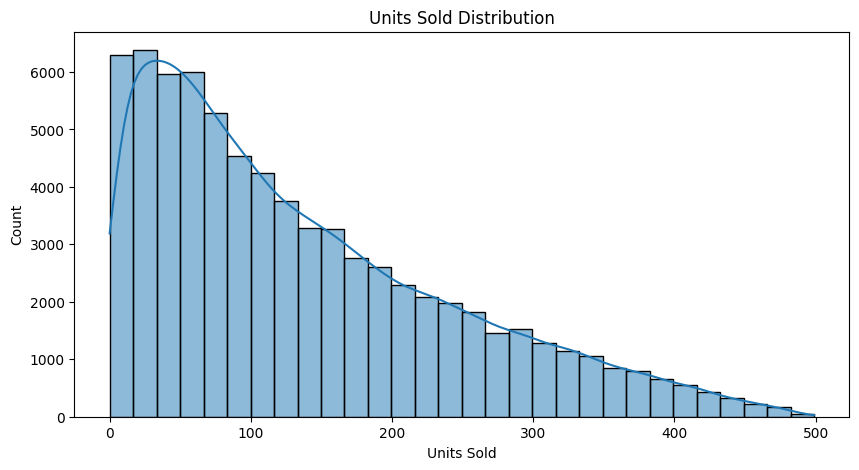

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Units Sold"],
    bins=30,
    kde=True
)

plt.title("Units Sold Distribution")

plt.show()

# Linear Regression

In [ ]:
X = df[
    [
        "Price",
        "Discount",
        "Inventory Level",
        "Competitor Pricing"
    ]
]

y = df["Units Sold"]

model = LinearRegression()

model.fit(X,y)

df["Predicted Sales"] = model.predict(X)

df[
    [
        "Units Sold",
        "Predicted Sales"
    ]
].head()

,Units Sold,Predicted Sales
0,127,115.286873
1,150,101.445079
2,65,51.680886
3,61,233.086418
4,14,82.504682


# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

df["Stockout"] = (
    df["Inventory Level"] < 200
).astype(int)

print(df["Stockout"].value_counts())

X = df[
    [
        "Price",
        "Units Sold"
    ]
]

y = df["Stockout"]

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(X, y)

df["Stockout Probability"] = (
    log_model.predict_proba(X)[:, 1] * 100
)

print(
    df[
        ["Stockout Probability"]
    ].head()
)

Stockout
0    48698
1    24402
Name: count, dtype: int64
   Stockout Probability
0             25.991535
1             18.658393
2             50.276143
3             51.825044
4             69.410191


# K-Means Clustering

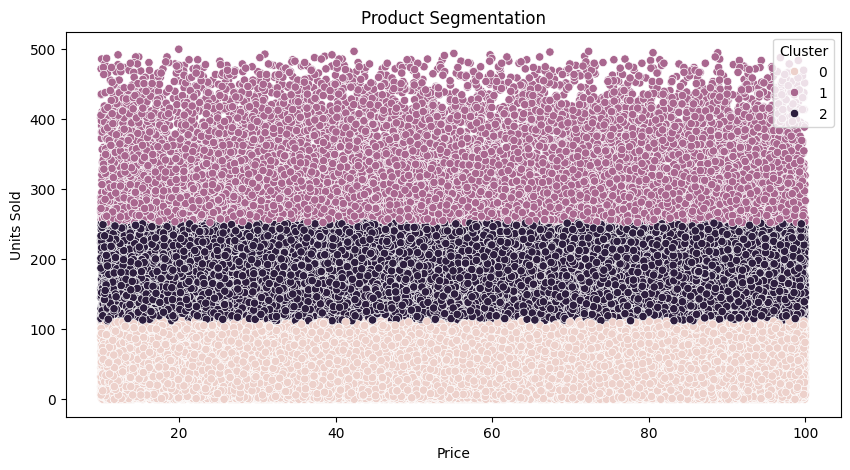

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    df[
        [
            "Price",
            "Units Sold"
        ]
    ]
)

plt.figure(figsize=(10,5))

sns.scatterplot(
    x=df["Price"],
    y=df["Units Sold"],
    hue=df["Cluster"]
)

plt.title("Product Segmentation")

plt.show()

# PCA

In [ ]:
pca = PCA(
    n_components=2
)

reduced = pca.fit_transform(
    df[
        [
            "Inventory Level",
            "Units Sold",
            "Units Ordered",
            "Demand Forecast",
            "Price",
            "Discount",
            "Competitor Pricing"
        ]
    ]
)